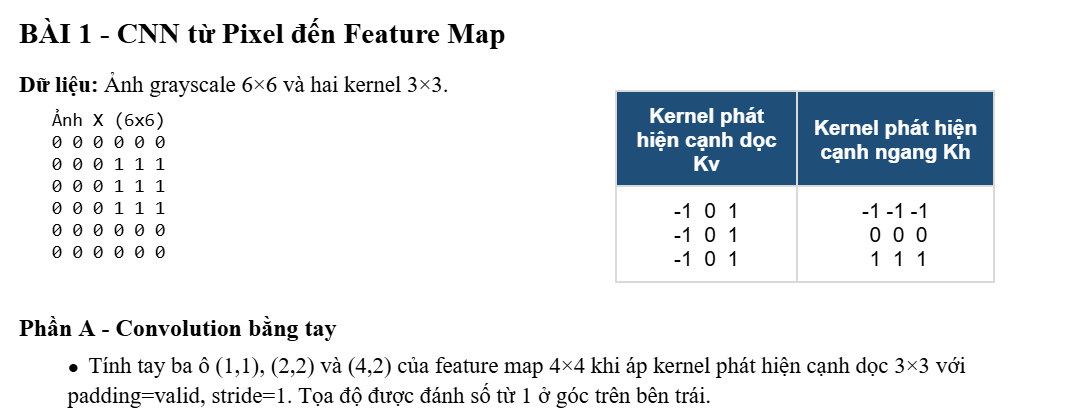

Feature map = 4 x 4 vì khi cho 1 cửa sổ 3x3 (filter) chạy sang phải và xuống dưới kể từ góc trên cùng bên trái thì ta thu được 4 bước sang phải và 4 bước xuống dưới.

# Tại ô (1,1), patch tương ứng ở ảnh X là:
```
0 0 0
0 0 0
0 0 0
```
Còn Kernal (Filter) dọc là:
```
-1 0 1
-1 0 1
-1 0 1
```
Tích chập của patch và kernal là:
0 * (-1) + 0 * 0 +0 * 1 + 0*(-1) + 0 * 0 + 0 * 1 + 0 * (-1) + 0 * 0 + 0 * 1  = 0

# Tại ô (2,2), patch tương ứng ở ảnh X là:

```
0 0 1
0 0 1
0 0 1
```

Còn Kernal (Filter) dọc là:

```
-1 0 1
-1 0 1
-1 0 1
```

Tích chập của patch và kernal là:

0 * (-1) + 0 * 0 + 1 * 1 + 0 * (-1) + 0 * 0 + 1 * 1 + 0 * (-1) + 0 * 0 + 1 * 1 = 3

Vậy giá trị tại ô (2,2) của feature map là 3.

# Tại ô (4,2), patch tương ứng ở ảnh X là:

```
0 0 1
0 0 0
0 0 0
```

Còn Kernal (Filter) dọc là:

```
-1 0 1
-1 0 1
-1 0 1
```

Tích chập của patch và kernal là:

0 * (-1) + 0 * 0 + 1 * 1 + 0 * (-1) + 0 * 0 + 0 * 1 + 0 * (-1) + 0 * 0 + 0 * 1 = 1

Vậy giá trị tại ô (4,2) của feature map là 1.


#Chạy thử tính feature map của kernal dọc:

In [ ]:
import numpy as np

X = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0]
])

Kv = np.array([[-1, 0, 1],
               [-1, 0, 1],
               [-1, 0, 1]])

feature_map = np.zeros((4, 4), dtype=int)
for i in range(4):
    for j in range(4):
        patch = X[i:i+3, j:j+3]
        feature_map[i, j] = np.sum(patch * Kv)

print(feature_map)
print("(1,1), (2,2), (4,2):",
      feature_map[0, 0], feature_map[1, 1], feature_map[3, 1])

# Kết quả: 0, 3, 1

[[0 2 2 0]
 [0 3 3 0]
 [0 2 2 0]
 [0 1 1 0]]
(1,1), (2,2), (4,2): 0 3 1


Phù hợp với kết quả em tính ở trên kia

#Chạy thử tính feature map của kernal ngang:

In [2]:
import numpy as np

X = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0]
])

Kh = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

feature_map_h = np.zeros((4, 4), dtype=int)

for i in range(4):
    for j in range(4):
        patch = X[i:i+3, j:j+3]
        feature_map_h[i, j] = np.sum(patch * Kh)

print(feature_map_h)
print("Giá trị tuyệt đối lớn nhất:", np.max(np.abs(feature_map_h)))

[[ 0  1  2  3]
 [ 0  0  0  0]
 [ 0 -1 -2 -3]
 [ 0 -1 -2 -3]]
Giá trị tuyệt đối lớn nhất: 3


#Kernel dọc và kernel ngang phản hồi mạnh như nhau trên ảnh này. Lý do là ảnh có cả cạnh dọc và cạnh ngang rõ rệt, và mức thay đổi pixel đều là từ 0 sang 1.

#Khi kiểm tra feature map của hai kernel, giá trị tuyệt đối lớn nhất của cả hai đều bằng 3. Vì vậy có thể nói hai kernel phản hồi mạnh tương đương trên ảnh mẫu này.


#Giải thích vì sao kernal phản hồi được mạnh tại các vùng pixel thay đổi rõ rêt:

Kernel phản hồi mạnh tại vùng có sự thay đổi pixel rõ rệt vì các giá trị âm và dương trong kernel được thiết kế có chủ đích để so sánh hai phía của một vùng ảnh.

Ở vùng phẳng, ví dụ toàn 0 hoặc toàn 1, các giá trị khi nhân với kernel thường triệt tiêu nhau nên kết quả gần 0. Nhưng tại vùng biên, ví dụ từ 0 chuyển sang 1, hai phía khác nhau rõ rệt nên tổng sau khi nhân có độ lớn lớn hơn.

Ví dụ với kernel dọc, nếu patch là vùng phẳng toàn số 1 thì kết quả tích chập bằng 0 vì các giá trị âm và dương của kernel triệt tiêu nhau.

Ngược lại, nếu patch có dạng:

```
0 0 1
0 0 1
0 0 1
```
tức là 1 cạnh dọc

thì kết quả là:

0 * (-1) + 0 * 0 + 1 * 1 + 0 * (-1) + 0 * 0 + 1 * 1 + 0 * (-1) + 0 * 0 + 1 * 1 = 3.

Vì vậy tại vùng có sự thay đổi pixel rõ rệt, giá trị đầu ra có độ lớn lớn hơn, nên kernel phản hồi mạnh hơn.


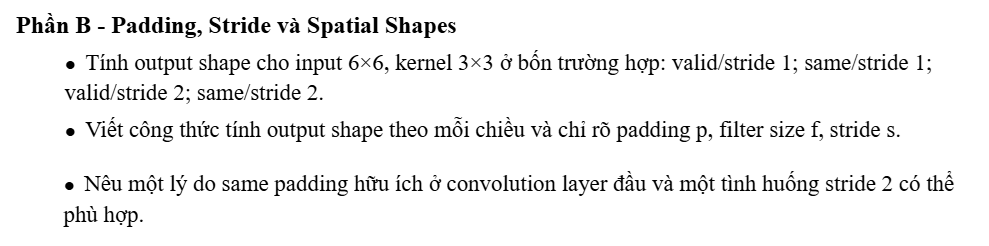

Hình dung kernel 3x3 giống như một cửa sổ trượt trên ảnh 6x6.

Đầu tiên xét trường hợp valid, stride = 1. Valid có nghĩa là không thêm viền vào ảnh, còn stride = 1 nghĩa là mỗi lần cửa sổ dịch đi 1 ô.

Nếu chỉ xét theo chiều ngang của ảnh có 6 ô, cửa sổ rộng 3 ô có thể đặt như sau:

```
[1 2 3] 4 5 6
1 [2 3 4] 5 6
1 2 [3 4 5] 6
1 2 3 [4 5 6]
```

Như vậy theo chiều ngang có 4 vị trí. Theo chiều dọc cũng tương tự có 4 vị trí, nên output là 4x4.

Tiếp theo với valid, stride = 2, cửa sổ vẫn không được đi ra ngoài ảnh nhưng mỗi lần sẽ nhảy 2 ô:

```
[1 2 3] 4 5 6
1 2 [3 4 5] 6
```

Lúc này chỉ có 2 vị trí theo chiều ngang và 2 vị trí theo chiều dọc, nên output là 2x2.

Với same, stride = 1, ta thêm một lớp padding vào xung quanh ảnh. Nếu chỉ nhìn theo một chiều thì có thể tưởng tượng từ:

```
1 2 3 4 5 6
```

thành:

```
0 1 2 3 4 5 6 0
```

Lúc này cửa sổ 3 ô có thể đặt được 6 vị trí mà vẫn tương ứng với 6 vị trí ban đầu của ảnh. Vì vậy output là 6x6.

Cuối cùng với same, stride = 2, ta vẫn có padding nhưng mỗi lần cửa sổ nhảy 2 ô. Vì vậy số vị trí giảm đi còn khoảng một nửa. Với input 6x6 thì output là 3x3.

# Từ cách đếm số vị trí của cửa sổ, ta có thể suy ra công thức tổng quát.

Gọi:

* n là kích thước input theo một chiều
* p là số ô padding ở mỗi bên
* f là kích thước filter
* s là stride

Sau khi padding, kích thước theo một chiều trở thành:

n + 2p

Filter chiếm f ô, nên phần khoảng cách mà filter có thể di chuyển là:

n + 2p - f

Mỗi lần filter dịch s ô, nên số bước dịch là:

(n + 2p - f) / s

Sau đó cộng thêm vị trí ban đầu, ta được công thức:

output = floor((n + 2p - f) / s) + 1

Áp dụng vào bốn trường hợp trên:

* valid, stride = 1: output = 4x4
* same, stride = 1: output = 6x6
* valid, stride = 2: output = 2x2
* same, stride = 2: output = 3x3


#Nêu một lý do same padding hữu ích ở convolution layer đầu và một tình huống stride 2 có thể phù hợp.

Same padding hữu ích khi ta muốn giữ nguyên kích thước của ảnh hoặc feature map sau khi convolution. Ví dụ ở những convolution layer đầu, ta thường chưa muốn làm ảnh nhỏ đi quá sớm vì có thể làm mất bớt thông tin ở các vùng biên. Khi dùng same padding với stride = 1, input 6x6 có thể cho output vẫn là 6x6.

Stride = 2 phù hợp khi ta muốn giảm kích thước feature map để giảm số lượng phép tính và làm mạng xử lý nhanh hơn. Ví dụ nếu feature map đang có kích thước 32x32 thì dùng stride = 2 có thể giảm xuống khoảng 16x16, nhờ đó các layer sau phải xử lý ít dữ liệu hơn.


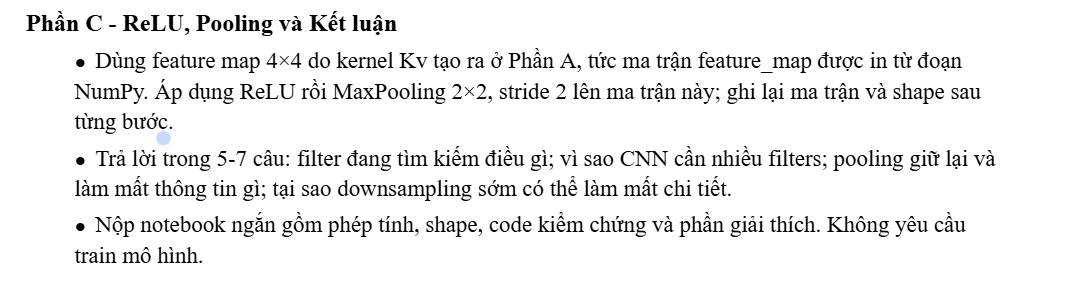

Feature map 4x4 thu được từ kernel Kv ở Phần A là:

```
0 2 2 0
0 3 3 0
0 2 2 0
0 1 1 0
```

Đầu tiên áp dụng ReLU. ReLU có công thức là:

ReLU(x) = max(0, x)

Tức là nếu giá trị âm thì đổi thành 0, còn giá trị dương thì giữ nguyên.

Trong feature map này không có giá trị âm nên sau ReLU ma trận vẫn giữ nguyên:

```
0 2 2 0
0 3 3 0
0 2 2 0
0 1 1 0
```

Shape sau ReLU vẫn là:

4x4

Tiếp theo áp dụng MaxPooling 2x2, stride = 2. Ta dùng một cửa sổ 2x2 và mỗi lần nhảy 2 ô.

Vùng đầu tiên:

```text
0 2
0 3
```

Giá trị lớn nhất là 3.

Vùng thứ hai:

```text
2 0
3 0
```

Giá trị lớn nhất là 3.

Vùng thứ ba:

```text
0 2
0 1
```

Giá trị lớn nhất là 2.

Vùng thứ tư:

```text
2 0
1 0
```

Giá trị lớn nhất là 2.

Vậy sau MaxPooling ta được:

```
3 3
2 2
```

Shape sau MaxPooling là:

2x2

Filter Kv đang tìm kiếm các vùng có sự thay đổi pixel theo chiều ngang, từ đó phát hiện ra các cạnh dọc trong ảnh. CNN cần nhiều filter vì mỗi filter có thể tìm một loại đặc trưng khác nhau, ví dụ cạnh dọc, cạnh ngang hoặc những mẫu phức tạp hơn. Pooling giữ lại những giá trị nổi bật nhất trong từng vùng nhỏ, ví dụ MaxPooling sẽ giữ lại giá trị lớn nhất. Tuy nhiên pooling cũng làm mất một phần thông tin về vị trí chính xác của các đặc trưng. Pooling giúp giảm kích thước feature map nên làm giảm số lượng phép tính ở các layer sau. Nếu downsampling quá sớm thì một số chi tiết nhỏ có thể bị mất trước khi CNN kịp nhận biết hoặc học được chúng.



In [1]:
import numpy as np

feature_map = np.array([
    [0, 2, 2, 0],
    [0, 3, 3, 0],
    [0, 2, 2, 0],
    [0, 1, 1, 0]
])

# ReLU
relu_map = np.maximum(0, feature_map)

print("Sau ReLU:")
print(relu_map)
print("Shape:", relu_map.shape)

# MaxPooling 2x2, stride 2
pooled_map = np.zeros((2, 2), dtype=int)

for i in range(2):
    for j in range(2):
        patch = relu_map[i*2:i*2+2, j*2:j*2+2]
        pooled_map[i, j] = np.max(patch)

print("\nSau MaxPooling:")
print(pooled_map)
print("Shape:", pooled_map.shape)

Sau ReLU:
[[0 2 2 0]
 [0 3 3 0]
 [0 2 2 0]
 [0 1 1 0]]
Shape: (4, 4)

Sau MaxPooling:
[[3 3]
 [2 2]]
Shape: (2, 2)
